In [40]:
import numpy as np
import matplotlib.pyplot as plt
from clusters_lattice_bigN import SpinConfiguration

In [41]:
def get_energies(n = 24, delta = 1., lamb = 1., k = np.array([0., 0.]), print_data = False):

    if k[0] == 0 and k[1] == 0:
        sc = SpinConfiguration(N = n, magnon_number=int(n/2)+0, delta = delta, lamb = lamb,
                            print_data=print_data, save_ham = n >= 24)
        en = sc.get_eigva_eigve(6)[0][0]
    
    sc_plus = SpinConfiguration(N = n, magnon_number=int(n/2)+1, delta = delta, lamb = lamb,
                                k = k, print_data=print_data, save_ham = n >= 24)
    
    en_plus = sc_plus.get_eigva_eigve(6)[0][0]

    if k[0] == 0 and k [1] == 0:
        return en, en_plus
    else:
        return en_plus


In [42]:
ns = np.arange(20, 28.001, 2, dtype = int)
lamb = .6
delta = 1.

gs_ens = []
ens_G = []
ens_X = []

for n in ns:
    _print = n > 24
    gs_en, en_G = get_energies(n, delta, lamb, print_data = _print)
    #en_X = get_energies(n, delta, lamb, k =np.array([1., 0.]), print_data = _print)
    gs_ens.append(gs_en)
    ens_G.append(en_G)
    #ens_X.append(en_X)
    print(f'Gap at Gamma for N={n}: {en_G-gs_en}')
    #print(f'Gap at X for N={n}: {en_X-gs_en}')
    print(f'{n} done')

Gap at Gamma for N=20: 1.191111419978979
20 done
Gap at Gamma for N=22: 1.1852552438861803
22 done
Gap at Gamma for N=24: 1.1809213654068689
24 done
Representatives loaded successfully
Trying to read hamiltonian
No hamiltonian to read or forced to start generation.


100%|██████████| 10/10 [01:18<00:00,  7.83s/it]


Getting H took: 94.48559 s
Finding eigvals and eigvecs took: 2.02166 s
Representatives loaded successfully
Trying to read hamiltonian
No hamiltonian to read or forced to start generation.


100%|██████████| 10/10 [01:10<00:00,  7.09s/it]


Getting H took: 86.29857 s
Finding eigvals and eigvecs took: 1.77856 s
Gap at Gamma for N=26: 1.1782502749834176
26 done
Representatives loaded successfully
Trying to read hamiltonian
No hamiltonian to read or forced to start generation.


100%|██████████| 2865720/2865720 [00:49<00:00, 57635.85it/s]
Process SpawnProcess-1460:
Process SpawnProcess-1459:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/concurrent/futures/process.py", line 242, in _process_worker
    call_item = call_queue.get(block=True)
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py", line 101, in get
    res = self._recv_bytes()
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/connection.py", line 216, in r

KeyboardInterrupt: 

In [ ]:
if delta == 1. and lamb == 1.:
    ns = np.append(ns, [32])
    gs_ens = np.append(gs_ens, [-21.76575088])
    ens_G = np.append(ens_G, [-21.45072937])
    ens_X = np.append(ens_X, [-19.32316589])

In [ ]:
data_matrix = np.zeros((len(ns), 4))
data_matrix[:, 0] = ns
data_matrix[:, 1] = gs_ens
data_matrix[:, 2] = ens_G
#data_matrix[:, 3] = ens_X
np.savetxt(fr'size_scaling/energy_{float(delta)}_{float(lamb)}.txt', data_matrix)

In [ ]:
data_matrix = np.loadtxt(fr'size_scaling/energy_{float(delta)}_{float(lamb)}.txt')
ns = data_matrix[:, 0]
gs_ens = data_matrix[:, 1]
ens_G = data_matrix[:, 2]
ens_X = data_matrix[:, 3]

[  1.33486955 500.00000008]


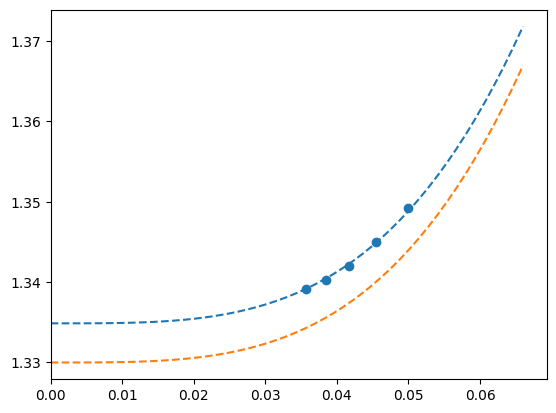

In [ ]:
from scipy.optimize import minimize

gaps = np.array(ens_G) - gs_ens

def fit(x, pars):
    b, c = pars
    return b + c * x**(7/2)

def cost(pars):
    return np.sum(np.square(fit(1/ns, pars) - np.array(gaps)))

x0 = [1.33, 500.]
fun = minimize(cost, x0)
print(fun.x)

x = np.linspace(0, 0.066, 51)
plt.plot(x, fit(x, fun.x), ls = '--')
plt.plot(x, fit(x, x0), ls = '--')

plt.scatter(1/ns, gaps)
plt.xlim([0, None])
#plt.ylim([0, None])
plt.show()

[   50.50546968 -1802.52900994  4674.4503105 ]


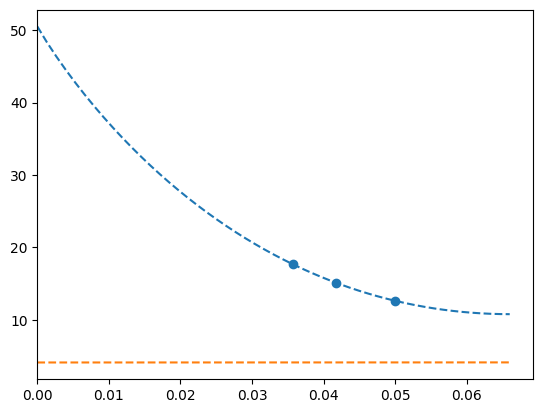

In [ ]:
gaps = np.array(ens_X) - gs_ens
gaps = np.array([gaps[0], gaps[2], gaps[4]])
_ns = ns.copy()
_ns = np.array([ns[0], ns[2], ns[4]])

def fit(x, pars):
    a, b, c = pars
    return a + b * x**(1) + c * x**(3/2)

def cost(pars):
    return np.sum(np.square(fit(1/_ns, pars) - np.array(gaps)))

x0 = [4.13, 0.2, -0.1]
fun = minimize(cost, x0)
print(fun.x)

x = np.linspace(0, 0.066, 51)
plt.plot(x, fit(x, fun.x), ls = '--')
plt.plot(x, fit(x, x0), ls = '--')

plt.scatter(1/_ns, gaps)
plt.xlim([0, None])
#plt.ylim([0, None])
plt.show()